In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/method.csv')

FEATURES = ['loc', 'rfc', 'cbo', 'parametersQty', 'loopQty', 'comparisonsQty', 'tryCatchQty', 'maxNestedBlocksQty']
TARGET = 'wmc'

data = df[FEATURES + [TARGET]].dropna()

X = data[FEATURES].values
y = data[TARGET].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (18869, 8)
y shape: (18869,)


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print(f'Training set: {X_train_norm.shape}')
print(f'Test set:     {X_test_norm.shape}')

Training set: (15095, 8)
Test set:     (3774, 8)


In [11]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    predictions = X @ w + b
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [12]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    predictions = X @ w + b
    error = predictions - y
    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

In [13]:
def gradient_descent(X, y, alpha=0.1, num_iters=1000):
    n = X.shape[1]
    w = np.zeros(n)
    b = 0.0
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            print(f'Iteration {i}: Cost = {cost:.4f}')

    return w, b, cost_history

In [14]:
w, b, cost_history = gradient_descent(X_train_norm, y_train, alpha=0.1, num_iters=1000)

Iteration 0: Cost = 3.0660
Iteration 100: Cost = 0.6919
Iteration 200: Cost = 0.6892
Iteration 300: Cost = 0.6891
Iteration 400: Cost = 0.6891
Iteration 500: Cost = 0.6891
Iteration 600: Cost = 0.6891
Iteration 700: Cost = 0.6891
Iteration 800: Cost = 0.6891
Iteration 900: Cost = 0.6891


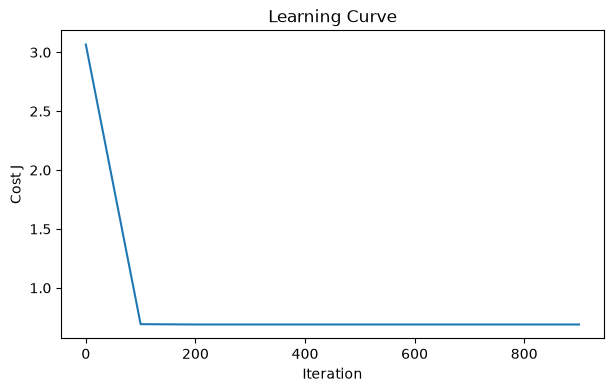

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(range(0, 1000, 100), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost J')
plt.title('Learning Curve')
plt.show()

In [16]:
y_pred = X_test_norm @ w + b

rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))
mae = np.mean(np.abs(y_pred - y_test))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2)

print(f'RMSE : {rmse:.3f}')
print(f'MAE  : {mae:.3f}')
print(f'R²   : {r2:.3f}')

RMSE : 1.197
MAE  : 0.487
R²   : 0.696


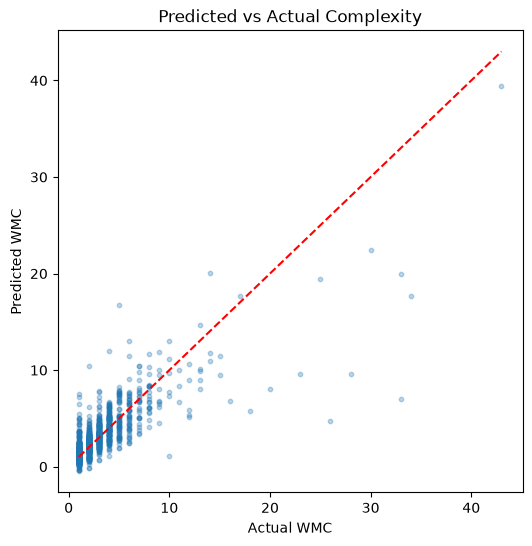

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual WMC')
plt.ylabel('Predicted WMC')
plt.title('Predicted vs Actual Complexity')
plt.show()